<a href="https://colab.research.google.com/github/Thiru-Vikram/titanic-survival-prediction/blob/main/titanic_survival_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Drop columns we don't need
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked with most common value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Convert Sex and Embarked to numbers
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


In [4]:
# Split data into features (X) and target (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


Model Accuracy: 82.68%


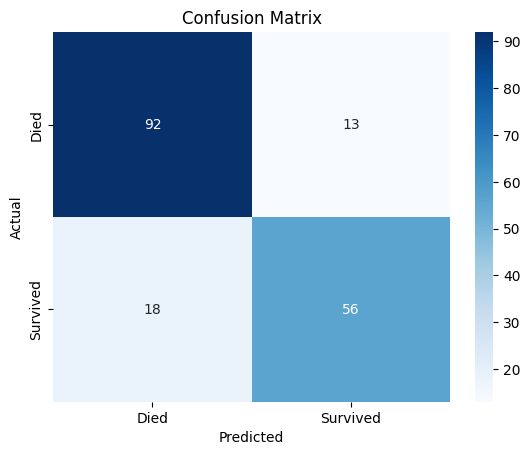

In [5]:
# Make predictions
y_pred = model.predict(X_test)

# Print accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

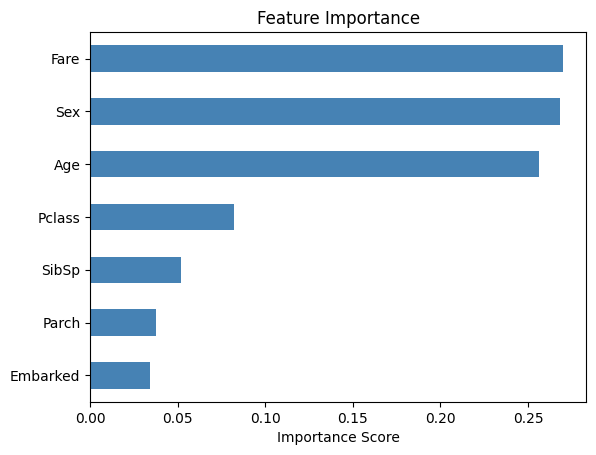

In [6]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.show()

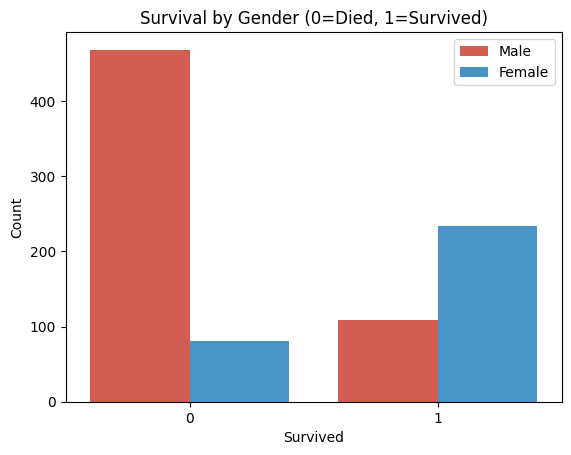

In [7]:
sns.countplot(x='Survived', hue='Sex', data=df, palette=['#e74c3c', '#3498db'])
plt.title('Survival by Gender (0=Died, 1=Survived)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.legend(labels=['Male', 'Female'])
plt.show()

In [8]:
print("=" * 40)
print("   TITANIC SURVIVAL PREDICTION")
print("=" * 40)
print(f"Total Passengers: {len(df)}")
print(f"Model Accuracy: 82.68%")
print(f"Algorithm: Random Forest Classifier")
print(f"Features Used: Pclass, Sex, Age, SibSp, Parch, Fare, Embarked")
print("=" * 40)
print("Key Findings:")
print("- Gender was the most important feature")
print("- females had higher survival rate than males")
print("- 1st class passengers survived more than 3rd class")
print("- Younger passengers had slightly higher survival rate")
print("=" * 40)

   TITANIC SURVIVAL PREDICTION
Total Passengers: 891
Model Accuracy: 82.68%
Algorithm: Random Forest Classifier
Features Used: Pclass, Sex, Age, SibSp, Parch, Fare, Embarked
Key Findings:
- Gender was the most important feature
- females had higher survival rate than males
- 1st class passengers survived more than 3rd class
- Younger passengers had slightly higher survival rate
